# Policy A: High-Density Weed Removal

This notebook validates and evaluates Policy A.

Policy A targets cells with a high weed index. During each simulation step,
it selects cells whose weed index is greater than or equal to a specified
threshold. The selected cells are ranked by weed index, and a fixed
proportion of weeds is removed from the highest-ranked cells.

This notebook performs two checks:

1. Validate the policy using a small manually defined grid.
2. Compare Policy A with the no-removal baseline using the Perth
   metropolitan dataset.

In [1]:
from pathlib import Path
import os


# Search the current directory and its parents for the repository root.
current_path = Path.cwd().resolve()

repo_root = next(
    path
    for path in (current_path, *current_path.parents)
    if (path / "src").is_dir()
)

# Use the repository root as the working directory.
os.chdir(repo_root)

print(f"Repository root: {repo_root}")
print(f"Current directory: {Path.cwd()}")

Repository root: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model
Current directory: C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


In [2]:
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.weed_policies

# Reload the module after editing the Python file.
importlib.reload(src.weed_policies)

from src.weed_policies import (
    HighDensityRemovalPolicy,
)

### Create a small test grid

The grid below contains weed-index values between `0` and `1`.

One cell contains `NaN` and is marked as invalid. Policy A must not select
this cell.

For this test, Policy A will:

- use `0.7` as the treatment threshold;
- remove `20%` of the weed index;
- treat at most three cells;
- charge `200` cost units per removed weed-index unit.

Although five valid cells meet the threshold, only the three cells with the
highest weed index should be selected.

In [4]:
# Create a small weed-index grid.
test_grid = np.array(
    [
        [0.90, 0.80, 0.60],
        [np.nan, 0.75, 0.95],
        [0.70, 0.40, 0.85],
    ],
    dtype=np.float32,
)

# Mark cells belonging to the simulation area.
test_mask = np.array(
    [
        [True, True, True],
        [False, True, True],
        [True, True, True],
    ],
    dtype=bool,
)

print("Weed grid:")
print(test_grid)

print("\nValid mask:")
print(test_mask)

Weed grid:
[[0.9  0.8  0.6 ]
 [ nan 0.75 0.95]
 [0.7  0.4  0.85]]

Valid mask:
[[ True  True  True]
 [False  True  True]
 [ True  True  True]]


### Configure Policy A

The policy object stores the treatment parameters.

Because `HighDensityRemovalPolicy` implements `__call__`, the object can be
called like a regular function:

```python
removal, cost = policy_a(test_grid, test_mask)
```

The policy returns:
- a two-dimensional array containing the removal amount for every cell;
- the treatment cost for the current step.

In [7]:
# Configure the high-density removal policy.
policy_a = HighDensityRemovalPolicy(
    threshold=0.7,
    removal_rate=0.2,
    max_cells=3,
    unit_cost=200.0,
)

policy_a

HighDensityRemovalPolicy(threshold=0.7, removal_rate=0.2, max_cells=3, unit_cost=200.0)

In [8]:
# Apply Policy A directly to the small grid.
removal_grid, treatment_cost = policy_a(
    test_grid,
    test_mask,
)

print("Removal grid:")
print(removal_grid)

print(
    f"\nTreatment cost: "
    f"{treatment_cost:.2f}"
)

Removal grid:
[[0.17999999 0.         0.        ]
 [0.         0.         0.19      ]
 [0.         0.         0.17      ]]

Treatment cost: 108.00


### Verify the policy result

The following assertions automatically check that the policy selected the
expected cells and returned the expected cost.

If all checks pass, the cell prints a confirmation message. If a result is
incorrect, Python raises an `AssertionError`.

In [9]:
# Define the expected removal array.
expected_removal = np.array(
    [
        [0.18, 0.00, 0.00],
        [0.00, 0.00, 0.19],
        [0.00, 0.00, 0.17],
    ],
    dtype=np.float32,
)

# Check that the removal amounts are correct.
np.testing.assert_allclose(
    removal_grid,
    expected_removal,
    rtol=1e-6,
    atol=1e-6,
)

# Check that the invalid cell was not selected.
assert removal_grid[1, 0] == 0

# Check that exactly three cells were selected.
assert np.count_nonzero(removal_grid) == 3

# Check the calculated treatment cost.
assert np.isclose(
    treatment_cost,
    108.0,
)

print("All Policy A unit checks passed.")

All Policy A unit checks passed.


### Visualise the small-grid result

The three panels show:

1. the weed index before treatment;
2. the amount removed by Policy A;
3. the weed index after treatment.

This visual check complements the assertions above.

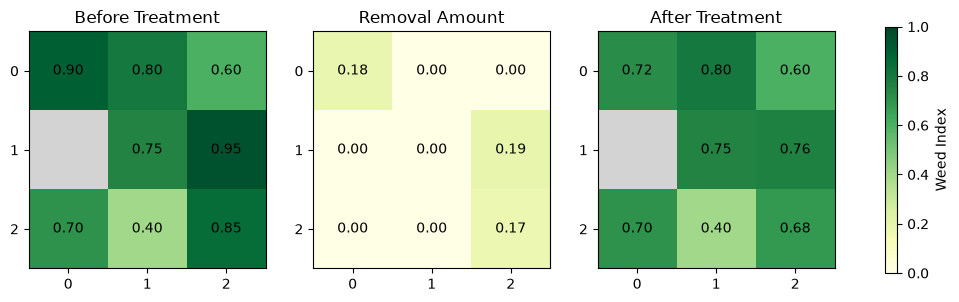

In [10]:
# Calculate the grid after applying the returned removal.
treated_grid = test_grid - removal_grid

# Preserve NaN outside the valid simulation area.
treated_grid[~test_mask] = np.nan

cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(13, 4),
)

images = [
    (test_grid, "Before Treatment"),
    (removal_grid, "Removal Amount"),
    (treated_grid, "After Treatment"),
]

for ax, (grid, title) in zip(axes, images):
    image = ax.imshow(
        grid,
        cmap=cmap,
        vmin=0,
        vmax=1,
    )

    ax.set_title(title)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks(range(grid.shape[0]))

    # Display each valid numerical value inside its cell.
    for row in range(grid.shape[0]):
        for column in range(grid.shape[1]):
            value = grid[row, column]

            if np.isfinite(value):
                ax.text(
                    column,
                    row,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black",
                )

fig.colorbar(
    image,
    ax=axes,
    label="Weed Index",
    shrink=0.8,
)

plt.show()

## Run Policy A with the Perth metropolitan data

After validating the policy independently, it is integrated with the full
weed simulator.

Two simulations are run under identical environmental conditions:

- **Baseline:** growth and diffusion only;
- **Policy A:** growth, diffusion and high-density removal.

Each simulation starts from the same population-density data and uses the
same model parameters. The only difference is whether Policy A is applied.

In [11]:
from src.data_loader import (
    load_locality_data,
)


# Load locality polygons and population-density data.
localities = load_locality_data()

# Select postcodes used as the Perth metropolitan study area.
metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

print(f"Number of polygons: {len(metro)}")
print(f"CRS: {metro.crs}")

metro[
    [
        "name",
        "postcode",
        "population_density_km2",
    ]
].head()

Number of polygons: 375
CRS: EPSG:7844


C:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


,name,postcode,population_density_km2
9,PALMYRA,6157,2345.786980
14,EAST FREMANTLE,6158,2106.591326
15,BICTON,6157,2345.786980
28,SUBIACO,6008,2255.266273
33,NORTHBRIDGE,6003,4293.051718


In [12]:
import src.weed_experiment

# Reload the experiment module after editing the Python file.
importlib.reload(src.weed_experiment)

from src.weed_experiment import (
    ExperimentConfig,
    run_experiment,
)

### Define the shared simulation configuration

Both simulations use the same:

- initialisation parameters;
- grid-cell size;
- growth rate;
- diffusion rate;
- carrying capacity;
- number of simulation steps;
- high-density threshold.

Using one shared configuration ensures that the comparison isolates the
effect of Policy A.

In [13]:
# Define parameters shared by the baseline and Policy A.
experiment_config = ExperimentConfig(
    pressure_coef=0.000783,
    cell_size=1000.0,
    w_min=0.05,
    w_max=1.0,
    growth_rate=0.02,
    diffusion_rate=0.01,
    carrying_capacity=1.0,
    steps=100,
    high_density_threshold=0.7,
    crs="EPSG:7850",
)

experiment_config

ExperimentConfig(pressure_coef=0.000783, cell_size=1000.0, w_min=0.05, w_max=1.0, growth_rate=0.02, diffusion_rate=0.01, carrying_capacity=1.0, steps=100, high_density_threshold=0.7, crs='EPSG:7850')

### Define Policy A for the full experiment

During every simulation step, Policy A:

1. finds valid cells with a weed index of at least `0.7`;
2. ranks those cells from the highest weed index to the lowest;
3. selects at most 100 cells;
4. removes 20% of the current weed index from each selected cell;
5. calculates the treatment cost from the amount removed.

In [14]:
# Configure Policy A for the full simulation.
policy_a = HighDensityRemovalPolicy(
    threshold=0.7,
    removal_rate=0.2,
    max_cells=100,
    unit_cost=200.0,
)

policy_a

HighDensityRemovalPolicy(threshold=0.7, removal_rate=0.2, max_cells=100, unit_cost=200.0)

### Run the baseline

No removal policy is passed to the baseline simulation. Therefore, only
growth and diffusion are applied.

In [17]:
# Run the no-removal baseline.
baseline_result = run_experiment(
    name="baseline",
    gdf=metro,
    config=experiment_config,
)

baseline_result.summary()

{'name': 'baseline',
 'steps': 100,
 'grid_height': 203,
 'grid_width': 124,
 'valid_cells': 6933,
 'initial_mean_weed': 0.8605745434761047,
 'final_mean_weed': 0.9814243912696838,
 'relative_change': 0.14042926171791265,
 'final_high_density_cells': 6933,
 'final_cost': 0.0}

### Run Policy A

Passing `policy_a` to `run_experiment` adds removal to the active simulation
modes.

A new simulator is created for this run, so Policy A starts from the same
initial conditions as the baseline.

In [18]:
# Run the simulation with Policy A.
policy_a_result = run_experiment(
    name="policy_a",
    gdf=metro,
    config=experiment_config,
    policy=policy_a,
)

policy_a_result.summary()

{'name': 'policy_a',
 'steps': 100,
 'grid_height': 203,
 'grid_width': 124,
 'valid_cells': 6933,
 'initial_mean_weed': 0.8605745434761047,
 'final_mean_weed': 0.8676178455352783,
 'relative_change': 0.008184418319793297,
 'final_high_density_cells': 6933,
 'final_cost': 386340.21875}

## Compare the summary metrics

The comparison includes:

- initial and final mean weed index;
- relative change in the mean weed index;
- final number of high-density cells;
- cumulative treatment cost.

The initial metrics should be identical because both simulations start from
the same data and configuration.

In [19]:
# Combine both experiment summaries into one table.
comparison = pd.DataFrame(
    [
        baseline_result.summary(),
        policy_a_result.summary(),
    ]
)

comparison[
    [
        "name",
        "initial_mean_weed",
        "final_mean_weed",
        "relative_change",
        "final_high_density_cells",
        "final_cost",
    ]
]

,name,initial_mean_weed,final_mean_weed,relative_change,final_high_density_cells,final_cost
0,baseline,0.860575,0.981424,0.140429,6933,0.00000
1,policy_a,0.860575,0.867618,0.008184,6933,386340.21875


In [20]:
# Confirm that both runs started from the same grid state.
np.testing.assert_allclose(
    baseline_result.history[0],
    policy_a_result.history[0],
    equal_nan=True,
)

# The baseline must not have a treatment cost.
assert np.isclose(
    baseline_result.final_cost,
    0.0,
)

# Policy A's cumulative cost must not decrease.
assert np.all(
    np.diff(policy_a_result.cost_history) >= 0
)

print(
    "The baseline and Policy A started "
    "from identical initial conditions."
)

print(
    "The cumulative cost checks passed."
)

The baseline and Policy A started from identical initial conditions.
The cumulative cost checks passed.


## Compare the mean weed index

The mean weed index represents the average weed condition across all valid
grid cells.

If Policy A is effective, its curve should remain below the no-removal
baseline for at least part of the simulation.

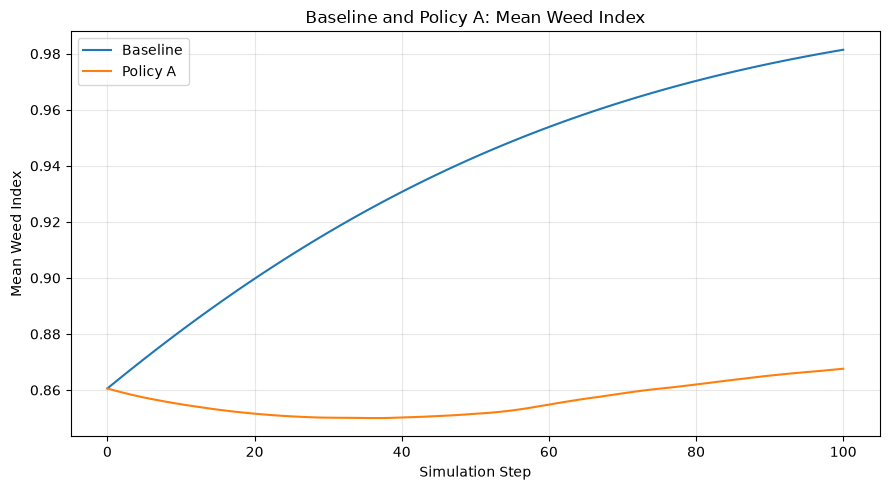

In [21]:
simulation_steps = np.arange(
    len(baseline_result.mean_weed)
)

fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    simulation_steps,
    baseline_result.mean_weed,
    label="Baseline",
)

ax.plot(
    simulation_steps,
    policy_a_result.mean_weed,
    label="Policy A",
)

ax.set_title(
    "Baseline and Policy A: Mean Weed Index"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Mean Weed Index")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare high-density cells

A high-density cell is a valid cell whose weed index is greater than or
equal to `0.7`.

Because Policy A directly targets these cells, this metric shows whether the
policy reduces or delays the number of high-density cells.

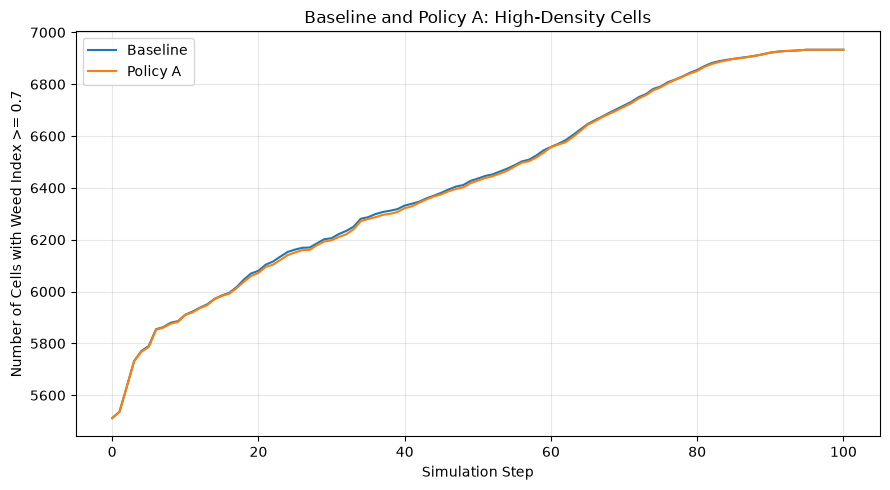

In [22]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    simulation_steps,
    baseline_result.high_density_cells,
    label="Baseline",
)

ax.plot(
    simulation_steps,
    policy_a_result.high_density_cells,
    label="Policy A",
)

ax.set_title(
    "Baseline and Policy A: High-Density Cells"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel(
    "Number of Cells with Weed Index >= 0.7"
)

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Plot the cumulative treatment cost

The baseline has no removal policy and therefore has zero treatment cost.

Policy A accumulates cost whenever weeds are removed. The cost is based on
the amount removed, rather than simply the number of selected cells.

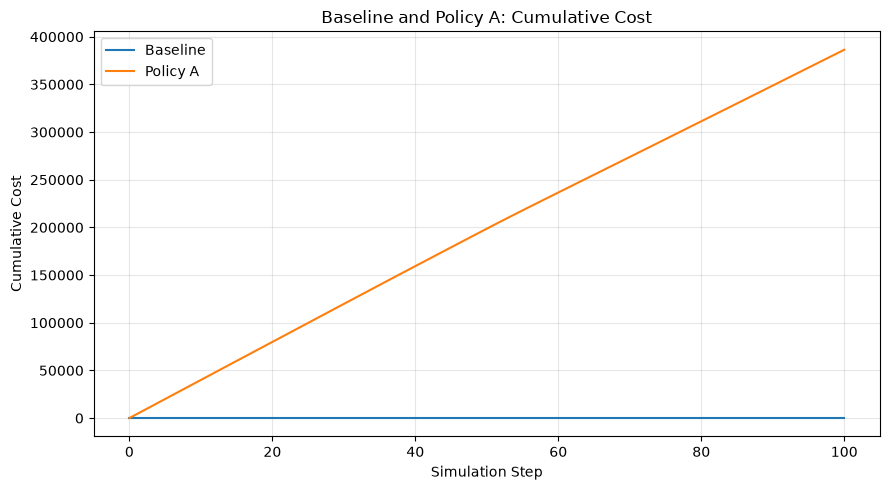

In [23]:
fig, ax = plt.subplots(
    figsize=(9, 5),
)

ax.plot(
    simulation_steps,
    baseline_result.cost_history,
    label="Baseline",
)

ax.plot(
    simulation_steps,
    policy_a_result.cost_history,
    label="Policy A",
)

ax.set_title(
    "Baseline and Policy A: Cumulative Cost"
)

ax.set_xlabel("Simulation Step")
ax.set_ylabel("Cumulative Cost")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Compare the final spatial distributions

The maps below compare the final weed-index grid after 100 simulation steps.

Both maps use the same colour scale:

- values near zero indicate a low weed index;
- values near one indicate a high weed index;
- grey cells are outside the simulation area.

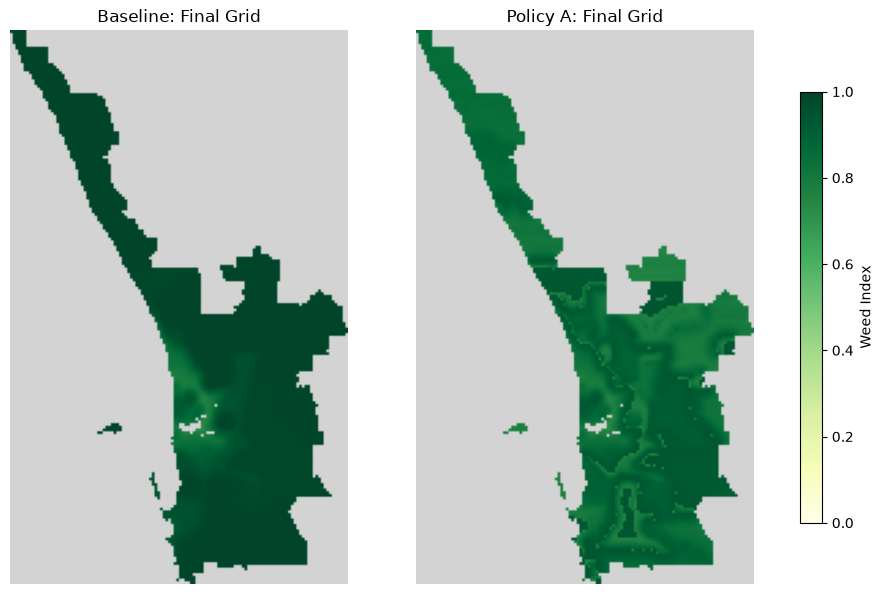

In [24]:
cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 8),
)

baseline_image = axes[0].imshow(
    baseline_result.history[-1],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[0].set_title("Baseline: Final Grid")
axes[0].axis("off")

axes[1].imshow(
    policy_a_result.history[-1],
    cmap=cmap,
    vmin=0,
    vmax=1,
)

axes[1].set_title("Policy A: Final Grid")
axes[1].axis("off")

fig.colorbar(
    baseline_image,
    ax=axes,
    label="Weed Index",
    shrink=0.7,
)

plt.show()